In [2]:
import pandas as pd
df=pd.read_csv('c:/data/guerry/data.csv')
df

,Unnamed: 0,dept,Region,Department,Crime_pers,Crime_prop,Literacy,Donations,Infants,Suicides,...,Crime_parents,Infanticide,Donation_clergy,Lottery,Desertion,Instruction,Prostitutes,Distance,Area,Pop1831
0,1,1,E,Ain,28870,15890,37,5098,33120,35039,...,71,60,69,41,55,46,13,218.372,5762,346.03
1,2,2,N,Aisne,26226,5521,51,8901,14572,12831,...,4,82,36,38,82,24,327,65.945,7369,513.00
2,3,3,C,Allier,26747,7925,13,10973,17044,114121,...,46,42,76,66,16,85,34,161.927,7340,298.26
3,4,4,E,Basses-Alpes,12935,7289,46,2733,23018,14238,...,70,12,37,80,32,29,2,351.399,6925,155.90
4,5,5,E,Hautes-Alpes,17488,8174,69,6962,23076,16171,...,22,23,64,79,35,7,1,320.280,5549,129.10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
81,82,86,W,Vienne,15010,4710,25,8922,35224,21851,...,20,1,44,40,38,65,18,170.523,6990,282.73
82,83,87,C,Haute-Vienne,16256,6402,13,13817,19940,33497,...,68,6,78,55,11,84,7,198.874,5520,285.13
83,84,88,E,Vosges,18835,9044,62,4040,14978,33029,...,58,34,5,14,85,11,43,174.477,5874,397.99
84,85,89,C,Yonne,18006,6516,47,4276,16616,12789,...,32,22,35,51,66,27,272,81.797,7427,352.49


<Axes: >

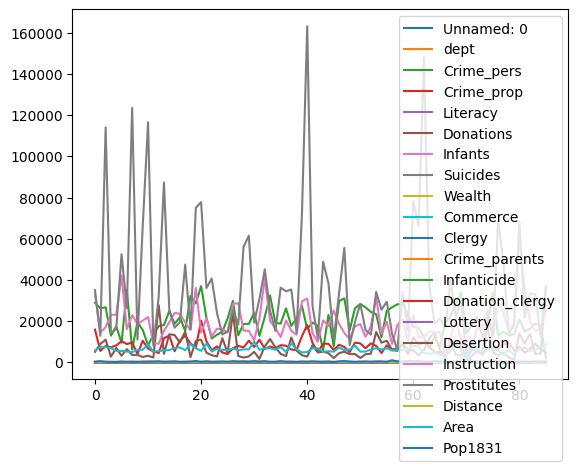

In [3]:
df.plot()

In [4]:
#결측값 제거
#df.dropna()는 복사본 만들어 제거, 원본 df는 그대로
df.dropna(inplace=True)
df.shape


(85, 24)

In [5]:
df2 = df[['Crime_prop','Literacy','Wealth','Distance']]

In [6]:
import statsmodels.formula.api as smf
#잔차의 제곱의 합을 최소로 하는 방식으로 회귀선을 그리는 방식
    #statsmodels.formula.api->ols(formula='종속변수 ~ 독립변수1+독립변수2+독립변수3)
model = smf.ols(formula='Crime_prop ~ Literacy + Wealth + Distance', data=df2).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:             Crime_prop   R-squared:                       0.277
Model:                            OLS   Adj. R-squared:                  0.250
Method:                 Least Squares   F-statistic:                     10.33
Date:                Wed, 14 Jan 2026   Prob (F-statistic):           7.89e-06
Time:                        16:49:49   Log-Likelihood:                -788.25
No. Observations:                  85   AIC:                             1584.
Df Residuals:                      81   BIC:                             1594.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   7118.5554   1162.059      6.126      0.000    4806.423    9430.688
Literacy     -41.6264     17.664     -2.357      0.021     -76.773      -6.480
Wealth        43.4753     12.868      3.378      0.001      17.871      69.080
Distance       2.4385      3.158      0.772      0.442      -3.845       8.722
==============================================================================
Omnibus:                       26.539   Durbin-Watson:                   1.857
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               45.437
Skew:                           1.238   Prob(JB):                     1.36e-10
Kurtosis:                       5.587   Cond. No.                         954.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

<Axes: xlabel='Literacy', ylabel='Crime_prop'>

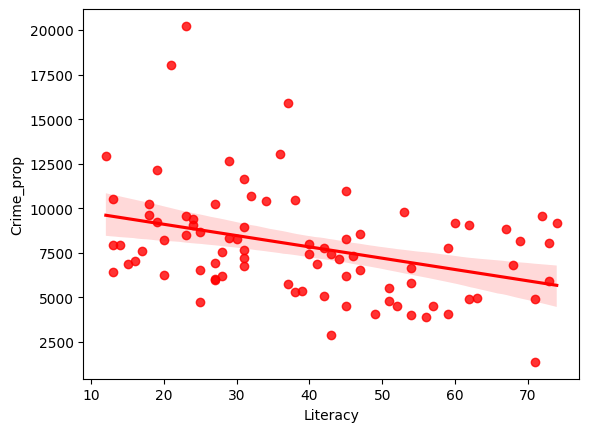

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.regplot(x='Literacy', y='Crime_prop', data=df, color='red')


<Axes: xlabel='Wealth', ylabel='Crime_prop'>

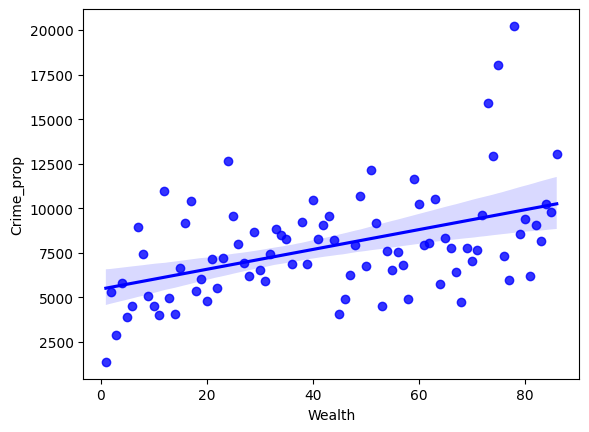

In [8]:
sns.regplot(x='Wealth', y='Crime_prop', data=df, color='blue')

<Axes: xlabel='Distance', ylabel='Crime_prop'>

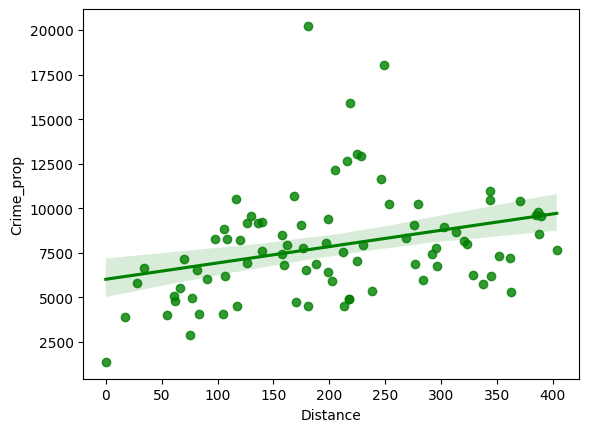

In [9]:
sns.regplot(x='Distance', y='Crime_prop', data=df, color='green')

<Axes: xlabel='Distance', ylabel='Crime_prop'>

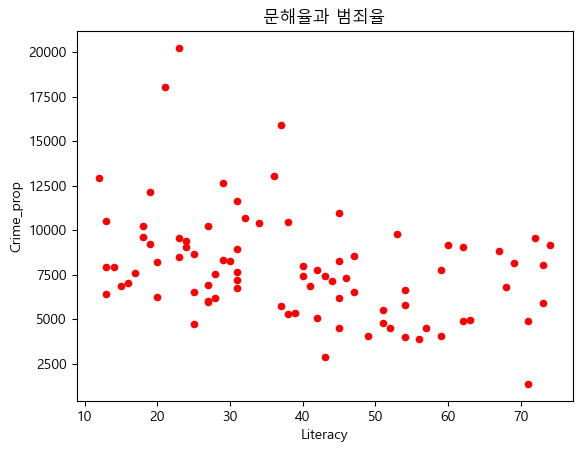

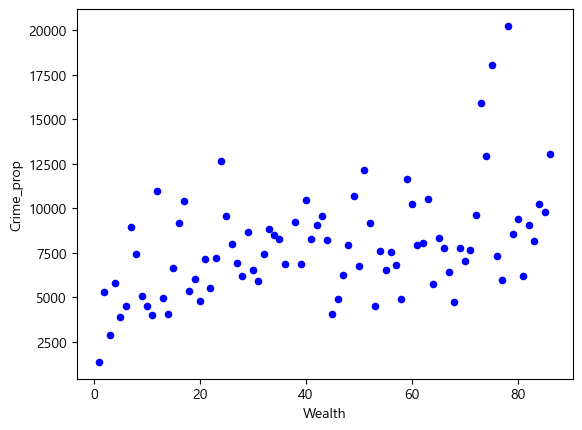

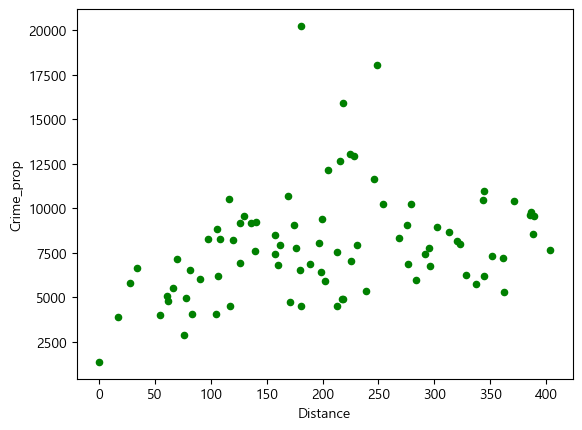

In [16]:
from matplotlib import font_manager, rc

font_name = font_manager.FontProperties(fname='c:/Windows/Fonts/malgun.ttf').get_name()
rc('font', family=font_name)

df.plot('Literacy','Crime_prop',kind='scatter',color='red', title='문해율과 범죄율')
df.plot('Wealth','Crime_prop', kind='scatter',color='blue')
df.plot('Distance', 'Crime_prop', kind='scatter',color='green')

In [11]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
X = df[['Literacy','Wealth','Distance']]
y = df['Crime_prop']
model.fit(X,y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [12]:
literacy = 80
wealth = 1
distance = 20

regionA = [literacy, wealth, distance]
crimeA = model.predict([regionA])
crimeA

c:\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([3880.68993851])

In [13]:
literacy = 10
wealth = 70
distance = 500

regionB = [literacy, wealth, distance]
crimeB = model.predict([regionB])
crimeB

c:\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([10964.81313077])

In [14]:
literacy = 50
wealth = 30
distance = 300

regionC = [literacy, wealth, distance]
crimeC = model.predict([regionC])
crimeC

c:\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([7073.04508028])